# Qwen235B FP8 vs INT4 Threshold Analysis

This notebook follows the benchmark-style workflow from the reference validation package, but uses the local verification artifacts in this workspace.

Comparison buckets:
- Honest: every available `inference_fp8_*` artifact compared against the FP8 config reference in `configs/inference_fp8`.
- Fraud: every available `inference_int4_*` artifact compared against the same FP8 config reference.

## Data Rules

The notebook does not use mismatch artifacts anymore.

It rebuilds comparison pairs directly from `inference_results.jsonl`:
- actual FP8 session output vs FP8 config output
- actual INT4 session output vs FP8 config output

The bounds are searched from the resulting honest/fraud distance distributions using the same lower/upper search pattern as the benchmark reference.

In [21]:
%load_ext autoreload
%autoreload 2

import importlib
import sys
from pathlib import Path
from pprint import pprint

module_candidates = [
    Path.cwd(),
    Path.cwd() / 'vllm' / 'poc' / 'verification',
    Path.cwd().parent / 'vllm' / 'poc' / 'verification',
]
verification_module_dir = next(
    (path.resolve() for path in module_candidates if (path / 'analysis_local.py').exists()),
    None,
 )
if verification_module_dir is None:
    raise FileNotFoundError(
        'Could not locate analysis_local.py. Run this notebook from the verification workspace.'
    )

if str(verification_module_dir) not in sys.path:
    sys.path.insert(0, str(verification_module_dir))

import analysis_local as analysis_local_module
analysis_local_module = importlib.reload(analysis_local_module)

default_verification_dir = analysis_local_module.default_verification_dir
build_threshold_payload = analysis_local_module.build_threshold_payload
session_summaries_to_rows = analysis_local_module.session_summaries_to_rows
plot_classification_results = analysis_local_module.plot_classification_results
plot_length_vs_distance_comparison = analysis_local_module.plot_length_vs_distance_comparison
plot_violin_comparison = analysis_local_module.plot_violin_comparison

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [22]:
verification_dir = default_verification_dir()
results_root = verification_dir / 'results'
reference_config_dir = verification_dir / 'configs' / 'inference_fp8'

model_name = 'qwen235B'
distance_floor_tokens = 100
length_mode = 'text_chars'
token_mismatch_policy = 'drop'
search_step = 0.001

print(f'verification_dir = {verification_dir}')
print(f'results_root = {results_root}')
print(f'reference_config_dir = {reference_config_dir}')
print(f'model_name = {model_name}')
print(f'distance_floor_tokens = {distance_floor_tokens}')
print(f'length_mode = {length_mode}')
print(f'token_mismatch_policy = {token_mismatch_policy}')
print(f'search_step = {search_step}')
print('honest = all inference_fp8_* artifacts vs FP8 config reference')
print('fraud = all inference_int4_* artifacts vs FP8 config reference')

verification_dir = /Users/daniilyankouski/develop/TRONITY-ONE/gonka/vllm/vllm/poc/verification
results_root = /Users/daniilyankouski/develop/TRONITY-ONE/gonka/vllm/vllm/poc/verification/results
reference_config_dir = /Users/daniilyankouski/develop/TRONITY-ONE/gonka/vllm/vllm/poc/verification/configs/inference_fp8
model_name = qwen235B
distance_floor_tokens = 100
length_mode = text_chars
token_mismatch_policy = drop
search_step = 0.001
honest = all inference_fp8_* artifacts vs FP8 config reference
fraud = all inference_int4_* artifacts vs FP8 config reference


## Build Honest/Fraud Datasets

In [23]:
payload = build_threshold_payload(
    results_root=results_root,
    reference_config_dir=reference_config_dir,
    distance_floor_tokens=distance_floor_tokens,
    length_mode=length_mode,
    token_mismatch_policy=token_mismatch_policy,
    step=search_step,
)

honest_items_dict = payload['honest_items_dict']
honest_distances_dict = payload['honest_distances_dict']
fraud_items_dict = payload['fraud_items_dict']
fraud_distances_dict = payload['fraud_distances_dict']
honest_distances = payload['honest_distances']
fraud_distances = payload['fraud_distances']
optimal_lower = payload['optimal_lower']
optimal_upper = payload['optimal_upper']
honest_classifications = payload['honest_classifications']
fraud_classifications = payload['fraud_classifications']
share_of_fraud_found = payload['share_of_fraud_found']
session_rows = session_summaries_to_rows(payload['session_summaries'])

print(f'honest sessions = {len(honest_items_dict)}')
print(f'fraud sessions = {len(fraud_items_dict)}')
print(f'honest distances = {len(honest_distances)}')
print(f'fraud distances = {len(fraud_distances)}')

for row in session_rows:
    pprint(row)

if optimal_lower is None or optimal_upper is None:
    raise ValueError('Could not compute bounds because one of the groups is empty after preprocessing.')

print(f'optimal_lower = {optimal_lower:.6f}')
print(f'optimal_upper = {optimal_upper:.6f}')
print(f'share_of_fraud_found = {share_of_fraud_found:.4f}')

Processed 1000 / 1000 items (dropped token mismatches: 0)
Processed 1000 / 1000 items (dropped token mismatches: 0)
Processed 56 / 250 items (dropped token mismatches: 194)
Processed 127 / 1000 items (dropped token mismatches: 873)
Optimal Lower Bound: 0.002067
Optimal Upper Bound: 0.003067
Best F1-Score: 0.5977
honest sessions = 2
fraud sessions = 2
honest distances = 2000
fraud distances = 183
{'artifact_dir': '/Users/daniilyankouski/develop/TRONITY-ONE/gonka/vllm/vllm/poc/verification/results/inference_fp8_20260324_070738',
 'average_time_per_prompt_seconds': 37.233,
 'bucket': 'honest',
 'dropped_token_mismatch': 0,
 'inference_model': 'Qwen/Qwen3-235B-A22B-Instruct-2507-FP8',
 'label': 'honest_fp8_20260324_070738',
 'matched_pairs': 1000,
 'max_distance': 0.001996007984031936,
 'mean_distance': 0.0011311835189786205,
 'median_distance': 0.0010015085316290135,
 'output_tokens_per_second': 10.18,
 'raw_records': 1000,
 'reference_model': 'Qwen/Qwen3-235B-A22B-Instruct-2507-FP8',
 't

honest classification counts = {'accepted': 2000, 'questionable': 0, 'fraud': 0}
fraud classification counts = {'accepted': 105, 'questionable': 28, 'fraud': 50}


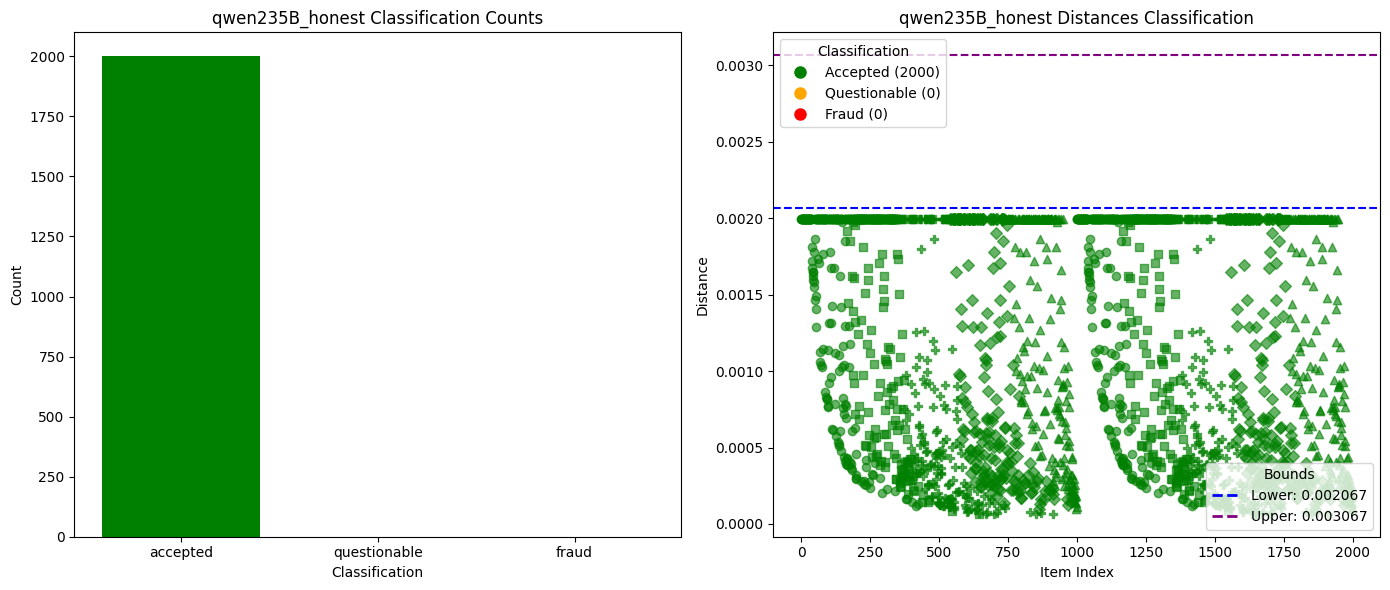

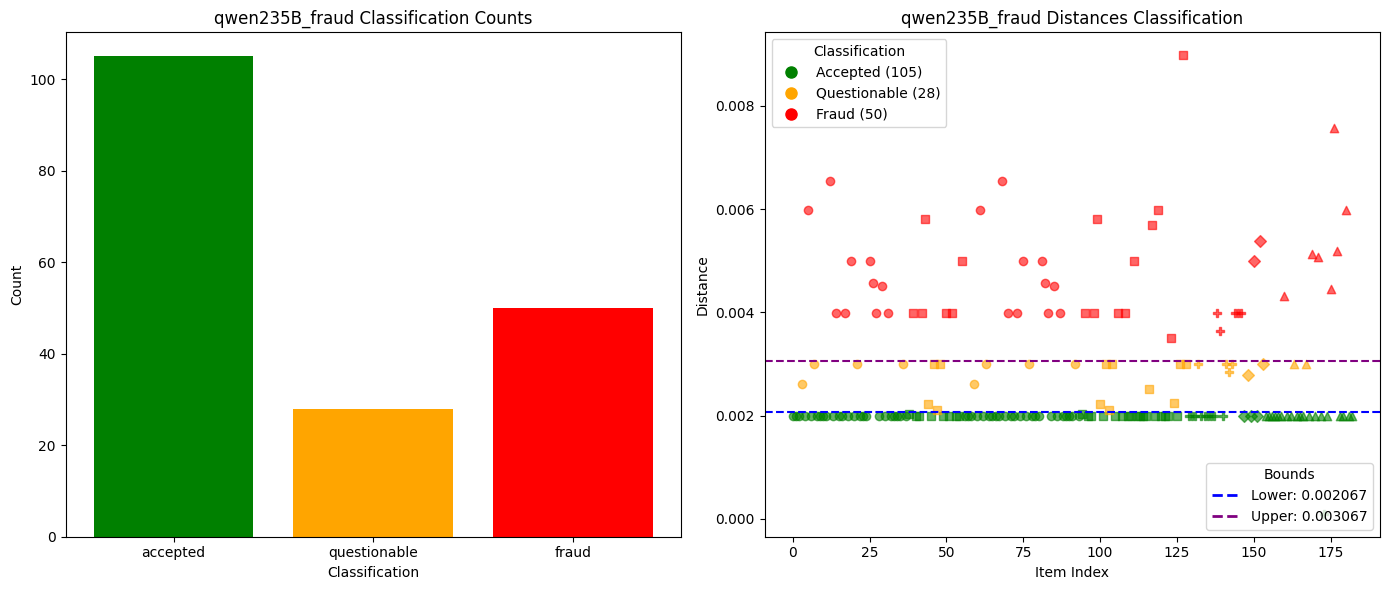

In [24]:
honest_languages = [
    str(item.get('language') or 'unk')
    for items in honest_items_dict.values()
    for item in items
]
fraud_languages = [
    str(item.get('language') or 'unk')
    for items in fraud_items_dict.values()
    for item in items
]

print('honest classification counts =', {
    label: honest_classifications.count(label)
    for label in ['accepted', 'questionable', 'fraud']
})
print('fraud classification counts =', {
    label: fraud_classifications.count(label)
    for label in ['accepted', 'questionable', 'fraud']
})

plot_classification_results(
    honest_distances,
    honest_classifications,
    optimal_lower,
    optimal_upper,
    title_prefix=f'{model_name}_honest',
    languages=honest_languages,
)
plot_classification_results(
    fraud_distances,
    fraud_classifications,
    optimal_lower,
    optimal_upper,
    title_prefix=f'{model_name}_fraud',
    languages=fraud_languages,
)

## Visualizations

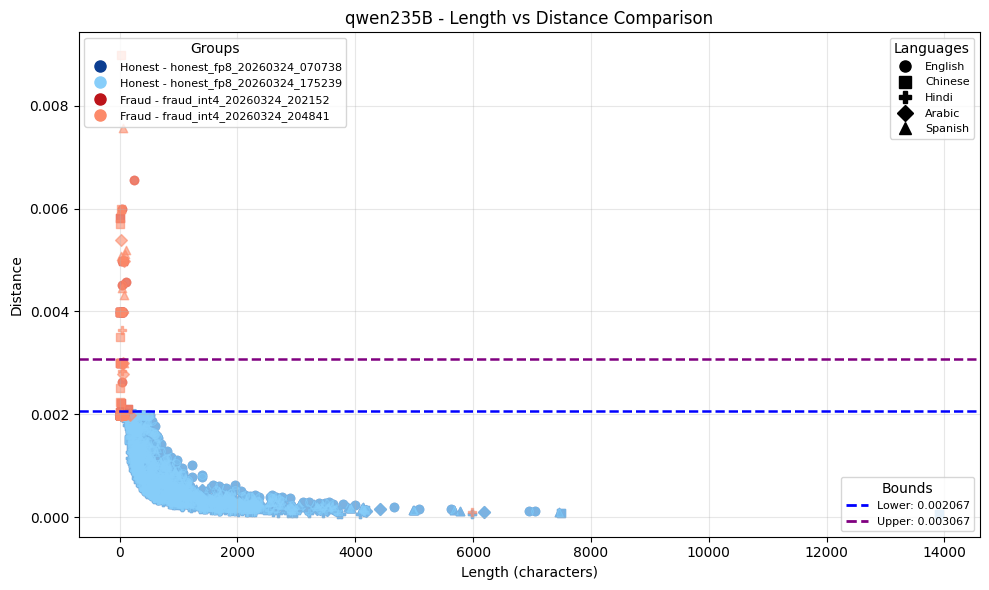

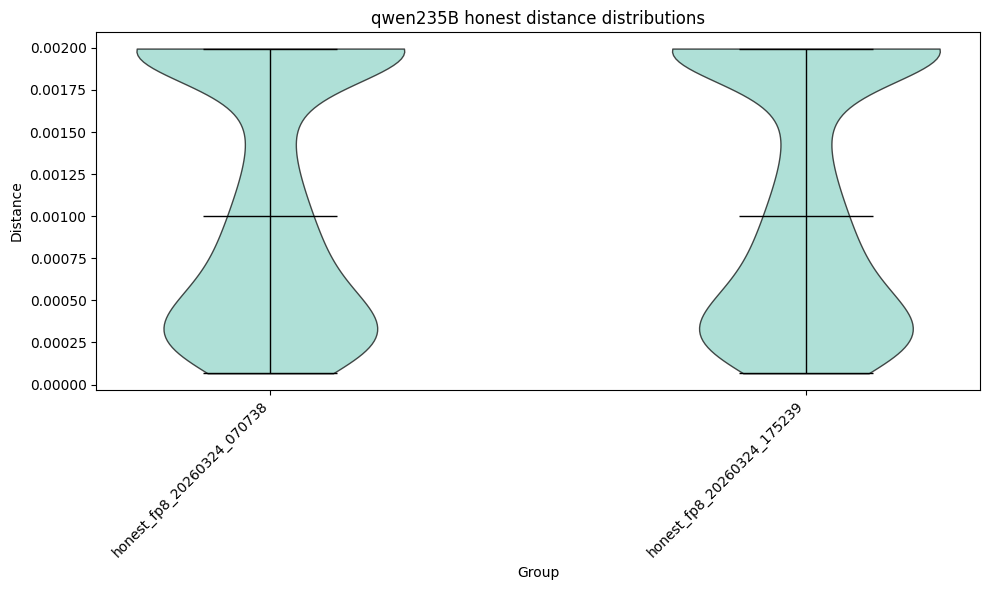

Mean and std per group:
  honest_fp8_20260324_070738: n=1000, mean=0.001131, std=0.000748
  honest_fp8_20260324_175239: n=1000, mean=0.001131, std=0.000748


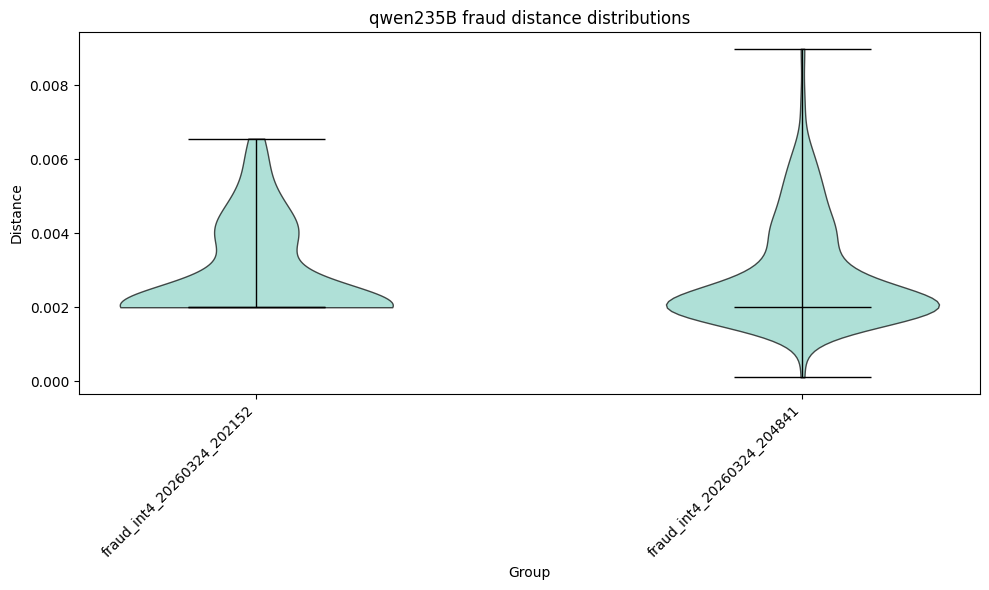

Mean and std per group:
  fraud_int4_20260324_202152: n=56, mean=0.002860, std=0.001255
  fraud_int4_20260324_204841: n=127, mean=0.002885, std=0.001406


In [25]:
plot_length_vs_distance_comparison(
    model_name,
    honest_items_dict,
    honest_distances_dict,
    fraud_items_dict,
    fraud_distances_dict,
    bounds=(optimal_lower, optimal_upper),
)

plot_violin_comparison(
    honest_distances_dict,
    title=f'{model_name} honest distance distributions',
)
plot_violin_comparison(
    fraud_distances_dict,
    title=f'{model_name} fraud distance distributions',
)